In [1]:


from google.colab import drive
drive.mount("/content/drive")

!apt-get -qq update
!apt-get -qq install -y ffmpeg
!pip -q install yt-dlp tabulate

import os
import json
import random
import shutil
import zipfile
import subprocess
from pathlib import Path


os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.50"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from joblib import dump, load

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

if DEVICE == "cuda":
    !nvidia-smi

Mounted at /content/drive
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 119.8 MB/s eta 0:00:00
DEVICE: cuda
numpy: 2.0.2
pandas: 2.2.2
Thu Apr 30 07:32:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=

In [2]:
# ============================================================
# Настройки проекта
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/lab2_howto100m")

METADATA_CSV = PROJECT_DIR / "HowTo100M_v1.csv"
VIDEO_DIR = PROJECT_DIR / "videos"
FEATURE_DIR = PROJECT_DIR / "videoprism_features"
RESULTS_DIR = PROJECT_DIR / "results"

for p in [PROJECT_DIR, VIDEO_DIR, FEATURE_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Датасет
# ----------------------------

LABEL_COLUMN = "category_2"

HOBBIES_CATEGORY_CANDIDATES = [
    "Hobbies and Crafts",
    "Hobbies",
    "Hobbies & Crafts",
    "Hobbies/Crafts",
]

# ----------------------------
# Скачивание видео
# ----------------------------

MAX_CLASSES = 5
VIDEOS_PER_CLASS = 40
CANDIDATE_MULTIPLIER = 20

CLIP_START = "00:00"
CLIP_END = "00:01:00"
MAX_FILESIZE = "150M"

VIDEO_FORMAT = "bv*[height<=360][ext=mp4]/bv*[height<=360]/b[height<=360]"

# ----------------------------
# VideoPrism
# ----------------------------

VIDEOPRISM_MODEL_NAME = "videoprism_public_v1_base"

NUM_FRAMES = 16
FRAME_SIZE = 288

# ----------------------------
# Обучение
# ----------------------------

MIN_SAMPLES_PER_CLASS = 5

BATCH_SIZE = 32
NUM_EPOCHS = 35
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 512
DROPOUT = 0.35
PATIENCE = 7
TOP_K = 5

print("PROJECT_DIR:", PROJECT_DIR)
print("METADATA_CSV:", METADATA_CSV)
print("VIDEO_DIR:", VIDEO_DIR)
print("FEATURE_DIR:", FEATURE_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_DIR: /content/drive/MyDrive/lab2_howto100m
METADATA_CSV: /content/drive/MyDrive/lab2_howto100m/HowTo100M_v1.csv
VIDEO_DIR: /content/drive/MyDrive/lab2_howto100m/videos
FEATURE_DIR: /content/drive/MyDrive/lab2_howto100m/videoprism_features
RESULTS_DIR: /content/drive/MyDrive/lab2_howto100m/results


In [3]:


HOWTO100M_ZIP_URL = "https://www.rocq.inria.fr/cluster-willow/amiech/howto100m/HowTo100M.zip"

def download_metadata_if_needed():
    if METADATA_CSV.exists():
        print("Metadata уже есть:", METADATA_CSV)
        return

    print("HowTo100M_v1.csv не найден.")
    print("Пробую скачать официальный архив metadata...")

    zip_path = PROJECT_DIR / "HowTo100M.zip"

    result = subprocess.run(
        ["wget", "-O", str(zip_path), HOWTO100M_ZIP_URL],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0 or not zip_path.exists() or zip_path.stat().st_size == 0:
        print(result.stderr[:2000])
        raise FileNotFoundError(
            "Не удалось автоматически скачать HowTo100M metadata. "
            "Скачай HowTo100M_v1.csv вручную и положи его в "
            "MyDrive/lab2_howto100m/HowTo100M_v1.csv"
        )

    print("Архив скачан. Распаковываю...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(PROJECT_DIR)

    candidates = list(PROJECT_DIR.rglob("HowTo100M_v1.csv"))

    if len(candidates) == 0:
        raise FileNotFoundError("Архив распакован, но HowTo100M_v1.csv не найден.")

    source_csv = candidates[0]

    if source_csv.resolve() == METADATA_CSV.resolve():
        print("Metadata уже распакован в нужное место:", METADATA_CSV)
    else:
        shutil.copy(source_csv, METADATA_CSV)
        print("Metadata скопирован в:", METADATA_CSV)


download_metadata_if_needed()

df = pd.read_csv(METADATA_CSV)

print("Размер metadata:", df.shape)
print("Колонки:", list(df.columns))
display(df.head())

Metadata уже есть: /content/drive/MyDrive/lab2_howto100m/HowTo100M_v1.csv
Размер metadata: (1238911, 5)
Колонки: ['video_id', 'category_1', 'category_2', 'rank', 'task_id']


,video_id,category_1,category_2,rank,task_id
0,nVbIUDjzWY4,Cars & Other Vehicles,Motorcycles,27,52907
1,CTPAZ2euJ2Q,Cars & Other Vehicles,Motorcycles,35,109057
2,rwmt7Cbuvfs,Cars & Other Vehicles,Motorcycles,99,52907
3,HnTLh99gcxY,Cars & Other Vehicles,Motorcycles,35,52907
4,EyP3HVhg1u0,Cars & Other Vehicles,Motorcycles,95,52906


In [4]:
# ============================================================
# Фильтрация Hobbies
# ============================================================

required_cols = {"video_id", "category_1", "category_2"}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"В metadata не хватает колонок: {missing_cols}")

df["video_id"] = df["video_id"].astype(str)
df["category_1"] = df["category_1"].astype(str)
df["category_2"] = df["category_2"].astype(str)

hobbies_df = df[df["category_1"].isin(HOBBIES_CATEGORY_CANDIDATES)].copy()

if len(hobbies_df) == 0:
    print("Не найдено точное название Hobbies.")
    print("Доступные category_1:")
    display(df["category_1"].value_counts().head(50))
    raise ValueError("Добавь правильное название Hobbies в HOBBIES_CATEGORY_CANDIDATES.")

hobbies_df = hobbies_df.dropna(subset=["video_id", "category_2"]).copy()

print("Всего видео в Hobbies:", len(hobbies_df))
print("Топ классов внутри Hobbies:")
display(hobbies_df["category_2"].value_counts().head(30))

Всего видео в Hobbies: 255865
Топ классов внутри Hobbies:


,count
category_2,
Crafts,182771
Games,12201
Woodworking,10803
Toys,9962
Tricks and Pranks,9936
Photography,6575
nan,5106
Collecting,4040
Painting,3397


In [5]:


top_classes = (
    hobbies_df["category_2"]
    .value_counts()
    .head(MAX_CLASSES)
    .index
    .tolist()
)

print("Выбранные классы:")
for cls in top_classes:
    print("-", cls)

candidate_df = (
    hobbies_df[hobbies_df["category_2"].isin(top_classes)]
    .groupby("category_2", group_keys=False)
    .apply(
        lambda x: x.sample(
            min(len(x), VIDEOS_PER_CLASS * CANDIDATE_MULTIPLIER),
            random_state=SEED,
        )
    )
    .reset_index(drop=True)
)

print("Кандидатов на скачивание:", candidate_df.shape)
display(candidate_df[["video_id", "category_1", "category_2"]].head(20))


def normalize_video_id(video_id: str) -> str:
    video_id = str(video_id)

    if "watch?v=" in video_id:
        video_id = video_id.split("watch?v=")[-1].split("&")[0]

    if "youtu.be/" in video_id:
        video_id = video_id.split("youtu.be/")[-1].split("?")[0]

    return video_id.strip()


def find_downloaded_video(video_id: str):
    video_id = normalize_video_id(video_id)

    candidates = (
        list(VIDEO_DIR.glob(f"vid_{video_id}.*")) +
        list(VIDEO_DIR.glob(f"{video_id}.*"))
    )

    for p in candidates:
        if p.suffix.lower() in [".mp4", ".webm", ".mkv", ".mov"]:
            return p

    return None


def video_exists(video_id: str) -> bool:
    return find_downloaded_video(video_id) is not None


def download_youtube_video(video_id: str) -> tuple:
    video_id = normalize_video_id(video_id)

    if video_exists(video_id):
        return True, "already_exists"

    url = f"https://www.youtube.com/watch?v={video_id}"
    output_template = str(VIDEO_DIR / f"vid_{video_id}.%(ext)s")

    cmd = [
        "yt-dlp",
        "--ignore-errors",
        "--no-warnings",
        "--restrict-filenames",
        "-f", VIDEO_FORMAT,
        "--download-sections", f"*{CLIP_START}-{CLIP_END}",
        "--force-keyframes-at-cuts",
        "--max-filesize", MAX_FILESIZE,
        "-o", output_template,
        url,
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if video_exists(video_id):
        return True, "downloaded"

    error_text = result.stderr.strip()
    if len(error_text) == 0:
        error_text = result.stdout.strip()

    return False, error_text[:500]


previous_csv = PROJECT_DIR / "downloaded_hobbies_subset.csv"

downloaded_rows = []
failed_rows = []

class_counter = {cls: 0 for cls in top_classes}

if previous_csv.exists():
    previous_df = pd.read_csv(previous_csv)

    if len(previous_df) > 0 and "category_2" in previous_df.columns:
        previous_df = previous_df[previous_df["category_2"].isin(top_classes)].copy()

        for _, row in previous_df.iterrows():
            video_id = normalize_video_id(row["video_id"])

            if video_exists(video_id):
                cls = row["category_2"]

                if class_counter.get(cls, 0) < VIDEOS_PER_CLASS:
                    row = row.copy()
                    row["video_id"] = video_id
                    row["video_path"] = str(find_downloaded_video(video_id))
                    downloaded_rows.append(row)
                    class_counter[cls] += 1

print("Уже найдено скачанных видео:")
print(class_counter)

for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    video_id = normalize_video_id(row["video_id"])
    cls = row["category_2"]

    if cls not in class_counter:
        continue

    if class_counter[cls] >= VIDEOS_PER_CLASS:
        continue

    ok, message = download_youtube_video(video_id)

    if ok:
        video_path = find_downloaded_video(video_id)

        new_row = row.copy()
        new_row["video_id"] = video_id
        new_row["video_path"] = str(video_path)
        new_row["download_status"] = message

        downloaded_rows.append(new_row)
        class_counter[cls] += 1

        print(f"[OK] {cls}: {class_counter[cls]}/{VIDEOS_PER_CLASS} | {video_id}")

    else:
        failed_row = row.copy()
        failed_row["video_id"] = video_id
        failed_row["error"] = message
        failed_rows.append(failed_row)

    if all(v >= VIDEOS_PER_CLASS for v in class_counter.values()):
        print("Достигли нужного количества видео по всем классам.")
        break

downloaded_df = pd.DataFrame(downloaded_rows)

if len(downloaded_df) > 0:
    downloaded_df = downloaded_df.drop_duplicates(subset=["video_id"]).reset_index(drop=True)

failed_df = pd.DataFrame(failed_rows)

downloaded_csv = PROJECT_DIR / "downloaded_hobbies_subset.csv"
failed_csv = PROJECT_DIR / "failed_downloads.csv"

downloaded_df.to_csv(downloaded_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

print("ИТОГ СКАЧИВАНИЯ")
print("Всего скачанных/найденных видео:", len(downloaded_df))

if len(downloaded_df) > 0:
    print("Скачано по классам:")
    display(downloaded_df["category_2"].value_counts())

print("Неудачных попыток:", len(failed_df))
print("Файл со скачанной выборкой:", downloaded_csv)
print("Файл с ошибками скачивания:", failed_csv)
print("Папка с видео:", VIDEO_DIR)

Выбранные классы:
- Crafts
- Games
- Woodworking
- Toys
- Tricks and Pranks
Кандидатов на скачивание: (4000, 5)


/tmp/ipykernel_7672/3739786288.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,video_id,category_1,category_2
0,I_bOhb4II_Y,Hobbies and Crafts,Crafts
1,BsWOF6oCFQI,Hobbies and Crafts,Crafts
2,N_zYXeZCc2w,Hobbies and Crafts,Crafts
3,_2tdS9zY7wY,Hobbies and Crafts,Crafts
4,wLUHrvByfck,Hobbies and Crafts,Crafts
5,Eicq-yvJNYE,Hobbies and Crafts,Crafts
6,DRYRRsjwK3M,Hobbies and Crafts,Crafts
7,b51JLHQkYLc,Hobbies and Crafts,Crafts
8,aitILhugghg,Hobbies and Crafts,Crafts
9,V8W2aSIJDx4,Hobbies and Crafts,Crafts


Уже найдено скачанных видео:
{'Crafts': 40, 'Games': 40, 'Woodworking': 40, 'Toys': 40, 'Tricks and Pranks': 40}


  0%|          | 0/4000 [00:00<?, ?it/s]

ИТОГ СКАЧИВАНИЯ
Всего скачанных/найденных видео: 200
Скачано по классам:


,count
category_2,
Crafts,40
Games,40
Toys,40
Tricks and Pranks,40
Woodworking,40


Неудачных попыток: 0
Файл со скачанной выборкой: /content/drive/MyDrive/lab2_howto100m/downloaded_hobbies_subset.csv
Файл с ошибками скачивания: /content/drive/MyDrive/lab2_howto100m/failed_downloads.csv
Папка с видео: /content/drive/MyDrive/lab2_howto100m/videos


In [6]:
# ============================================================
# Проверка скачанных видео
# ============================================================

downloaded_csv = PROJECT_DIR / "downloaded_hobbies_subset.csv"

if not downloaded_csv.exists():
    raise FileNotFoundError("Не найден downloaded_hobbies_subset.csv. Сначала запусти ячейку 5.")

downloaded_df = pd.read_csv(downloaded_csv)

print("Видео в таблице:", downloaded_df.shape)

if len(downloaded_df) == 0:
    raise ValueError(
        "Не скачалось ни одного видео. "
        "Увеличь CANDIDATE_MULTIPLIER или уменьши MAX_CLASSES."
    )

print("Распределение по классам:")
display(downloaded_df["category_2"].value_counts())

video_files = list(VIDEO_DIR.glob("*"))

print("Файлов в VIDEO_DIR:", len(video_files))
display(pd.DataFrame({"file": [str(p) for p in video_files[:20]]}))

Видео в таблице: (200, 7)
Распределение по классам:


,count
category_2,
Crafts,40
Games,40
Toys,40
Tricks and Pranks,40
Woodworking,40


Файлов в VIDEO_DIR: 203


,file
0,/content/drive/MyDrive/lab2_howto100m/videos/v...
1,/content/drive/MyDrive/lab2_howto100m/videos/v...
2,/content/drive/MyDrive/lab2_howto100m/videos/v...
3,/content/drive/MyDrive/lab2_howto100m/videos/v...
4,/content/drive/MyDrive/lab2_howto100m/videos/v...
5,/content/drive/MyDrive/lab2_howto100m/videos/v...
6,/content/drive/MyDrive/lab2_howto100m/videos/v...
7,/content/drive/MyDrive/lab2_howto100m/videos/v...
8,/content/drive/MyDrive/lab2_howto100m/videos/v...
9,/content/drive/MyDrive/lab2_howto100m/videos/v...


In [7]:
# ============================================================
# Установка VideoPrism
# ============================================================

!pip -q uninstall -y tensorflow tensorflow-cpu tf-keras keras protobuf
!pip -q uninstall -y tensorflow tensorflow-cpu tf-keras keras protobuf

!pip -q install "protobuf>=5.28.0,<6.0.0"
!pip -q install "tensorflow-cpu==2.19.0"

!pip -q install absl-py einops einshape flax huggingface-hub sentencepiece

!rm -rf /content/videoprism_repo
!git clone --quiet --depth=1 https://github.com/google-deepmind/videoprism.git /content/videoprism_repo

%cd /content/videoprism_repo
!pip -q install --no-deps .
%cd /content

print("VideoPrism установлен")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 27.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-hub 0.16.1 requires tf-keras>=2.14.1, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.9/251.9 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.2 MB/s eta 0:00:00
/content/videoprism_repo
  Preparing metadata (setup.py) ... done
/content
VideoPrism установлен


In [8]:


import sys
sys.path.append("/content/videoprism_repo")

import tensorflow as tf
import jax
import jax.numpy as jnp

from videoprism import models as vp

print("TensorFlow version:", tf.__version__)
print("JAX devices:", jax.devices())
print("VideoPrism import OK")

TensorFlow version: 2.19.0
JAX devices: [CudaDevice(id=0)]
VideoPrism import OK


In [9]:



import cv2

print("Загружаю VideoPrism:", VIDEOPRISM_MODEL_NAME)

flax_model = vp.get_model(VIDEOPRISM_MODEL_NAME)
loaded_state = vp.load_pretrained_weights(VIDEOPRISM_MODEL_NAME)

@jax.jit
def videoprism_forward(video_batch):
    output = flax_model.apply(loaded_state, video_batch, train=False)
    return output


def extract_vector_from_videoprism_output(output) -> np.ndarray:
    if isinstance(output, (tuple, list)):
        output = output[0]

    if isinstance(output, dict):
        preferred_keys = [
            "embedding",
            "embeddings",
            "features",
            "feature",
            "pre_logits",
            "last_hidden_state",
            "encoder_output",
        ]

        found = False

        for key in preferred_keys:
            if key in output:
                output = output[key]
                found = True
                break

        if not found:
            first_key = list(output.keys())[0]
            output = output[first_key]

    arr = np.asarray(output)

    if arr.ndim >= 2 and arr.shape[0] == 1:
        arr = arr[0]

    if arr.ndim == 1:
        vec = arr
    else:
        vec = arr.mean(axis=tuple(range(arr.ndim - 1)))

    vec = np.asarray(vec, dtype=np.float32).reshape(-1)
    vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)

    return vec


def read_video_frames(video_path: Path, num_frames: int = NUM_FRAMES, size: int = FRAME_SIZE) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Не удалось открыть видео: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Не удалось определить количество кадров: {video_path}")

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (size, size), interpolation=cv2.INTER_AREA)
        frame = frame.astype(np.float32) / 255.0

        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"Не удалось извлечь кадры: {video_path}")

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    frames = np.stack(frames[:num_frames], axis=0).astype(np.float32)

    return frames


def feature_path_for_video_id(video_id: str) -> Path:
    video_id = normalize_video_id(video_id)
    return FEATURE_DIR / f"vid_{video_id}.npy"


def extract_videoprism_feature(video_id: str, video_path: Path) -> Path:
    out_path = feature_path_for_video_id(video_id)

    if out_path.exists():
        return out_path

    frames = read_video_frames(video_path)

    video_batch = frames[None, ...]

    output = videoprism_forward(jnp.asarray(video_batch))
    vector = extract_vector_from_videoprism_output(output)

    np.save(out_path, vector)

    return out_path


downloaded_df = pd.read_csv(PROJECT_DIR / "downloaded_hobbies_subset.csv")

feature_rows = []
failed_feature_rows = []

for _, row in tqdm(downloaded_df.iterrows(), total=len(downloaded_df)):
    video_id = normalize_video_id(row["video_id"])
    video_path = find_downloaded_video(video_id)

    if video_path is None:
        failed_row = row.copy()
        failed_row["error"] = "video_file_not_found"
        failed_feature_rows.append(failed_row)
        continue

    try:
        feature_path = extract_videoprism_feature(video_id, video_path)

        new_row = row.copy()
        new_row["video_id"] = video_id
        new_row["video_path"] = str(video_path)
        new_row["feature_path"] = str(feature_path)

        feature_rows.append(new_row)

    except Exception as e:
        failed_row = row.copy()
        failed_row["video_id"] = video_id
        failed_row["video_path"] = str(video_path)
        failed_row["error"] = str(e)
        failed_feature_rows.append(failed_row)

features_df = pd.DataFrame(feature_rows)
failed_features_df = pd.DataFrame(failed_feature_rows)

features_csv = PROJECT_DIR / "hobbies_with_videoprism_features.csv"
failed_features_csv = PROJECT_DIR / "failed_feature_extraction.csv"

features_df.to_csv(features_csv, index=False)
failed_features_df.to_csv(failed_features_csv, index=False)

print("Видео с извлечёнными фичами:", features_df.shape)

if len(features_df) > 0:
    print("По классам:")
    display(features_df["category_2"].value_counts())

print("CSV с фичами сохранён:", features_csv)
print("Ошибки извлечения фичей:", failed_features_csv)
print("Папка с фичами:", FEATURE_DIR)

Загружаю VideoPrism: videoprism_public_v1_base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flax_base_f16r288_repeated.npz:   0%|          | 0.00/457M [00:00<?, ?B/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Видео с извлечёнными фичами: (200, 8)
По классам:


,count
category_2,
Crafts,40
Games,40
Toys,40
Tricks and Pranks,40
Woodworking,40


CSV с фичами сохранён: /content/drive/MyDrive/lab2_howto100m/hobbies_with_videoprism_features.csv
Ошибки извлечения фичей: /content/drive/MyDrive/lab2_howto100m/failed_feature_extraction.csv
Папка с фичами: /content/drive/MyDrive/lab2_howto100m/videoprism_features


In [10]:
# ============================================================
# Подготовка данных для обучения
# ============================================================

features_csv = PROJECT_DIR / "hobbies_with_videoprism_features.csv"

if not features_csv.exists():
    raise FileNotFoundError("Не найден hobbies_with_videoprism_features.csv. Сначала запусти ячейку 9.")

data_df = pd.read_csv(features_csv)

print("Исходно видео с фичами:", data_df.shape)
display(data_df.head())

data_df["feature_exists"] = data_df["feature_path"].apply(lambda p: Path(p).exists())
data_df = data_df[data_df["feature_exists"]].copy()

print("После проверки существования .npy:", data_df.shape)

class_counts = data_df[LABEL_COLUMN].value_counts()

print("Распределение классов ДО фильтра:")
display(class_counts)

valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

data_df = data_df[data_df[LABEL_COLUMN].isin(valid_classes)].copy()
data_df = data_df.reset_index(drop=True)

print("После удаления редких классов:", data_df.shape)
print("Классов осталось:", data_df[LABEL_COLUMN].nunique())

display(data_df[LABEL_COLUMN].value_counts())

if data_df[LABEL_COLUMN].nunique() < 2:
    raise ValueError(
        "Осталось меньше двух классов. "
        "Нужно скачать/обработать больше видео."
    )


def load_feature(path: str) -> np.ndarray:
    arr = np.load(path)
    arr = np.asarray(arr, dtype=np.float32)

    if arr.ndim == 1:
        vec = arr
    else:
        vec = arr.mean(axis=tuple(range(arr.ndim - 1)))

    vec = vec.reshape(-1).astype(np.float32)
    vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)

    return vec


sample_vec = load_feature(data_df.iloc[0]["feature_path"])
FEATURE_DIM = sample_vec.shape[0]

print("FEATURE_DIM:", FEATURE_DIM)

label_encoder = LabelEncoder()
data_df["label"] = label_encoder.fit_transform(data_df[LABEL_COLUMN])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("class_names:", class_names)
print("num_classes:", num_classes)

label_mapping = {int(i): cls for i, cls in enumerate(class_names)}

with open(RESULTS_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, indent=2, ensure_ascii=False)

train_val_df, test_df = train_test_split(
    data_df,
    test_size=0.2,
    random_state=SEED,
    stratify=data_df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=SEED,
    stratify=train_val_df["label"],
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

train_df.to_csv(RESULTS_DIR / "train_split.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split.csv", index=False)
data_df.to_csv(RESULTS_DIR / "dataset_used.csv", index=False)

print("Split-файлы сохранены в:", RESULTS_DIR)

Исходно видео с фичами: (200, 8)


,video_id,category_1,category_2,rank,task_id,video_path,download_status,feature_path
0,I_bOhb4II_Y,Hobbies and Crafts,Crafts,164,57768,/content/drive/MyDrive/lab2_howto100m/videos/v...,already_exists,/content/drive/MyDrive/lab2_howto100m/videopri...
1,N_zYXeZCc2w,Hobbies and Crafts,Crafts,18,63139,/content/drive/MyDrive/lab2_howto100m/videos/v...,already_exists,/content/drive/MyDrive/lab2_howto100m/videopri...
2,_2tdS9zY7wY,Hobbies and Crafts,Crafts,36,46579,/content/drive/MyDrive/lab2_howto100m/videos/v...,already_exists,/content/drive/MyDrive/lab2_howto100m/videopri...
3,wLUHrvByfck,Hobbies and Crafts,Crafts,110,104661,/content/drive/MyDrive/lab2_howto100m/videos/v...,already_exists,/content/drive/MyDrive/lab2_howto100m/videopri...
4,Eicq-yvJNYE,Hobbies and Crafts,Crafts,15,93260,/content/drive/MyDrive/lab2_howto100m/videos/v...,already_exists,/content/drive/MyDrive/lab2_howto100m/videopri...


После проверки существования .npy: (200, 9)
Распределение классов ДО фильтра:


,count
category_2,
Crafts,40
Games,40
Toys,40
Tricks and Pranks,40
Woodworking,40


После удаления редких классов: (200, 9)
Классов осталось: 5


,count
category_2,
Crafts,40
Games,40
Toys,40
Tricks and Pranks,40
Woodworking,40


FEATURE_DIM: 768
class_names: ['Crafts', 'Games', 'Toys', 'Tricks and Pranks', 'Woodworking']
num_classes: 5
Train: (120, 10)
Val: (40, 10)
Test: (40, 10)
Split-файлы сохранены в: /content/drive/MyDrive/lab2_howto100m/results


In [11]:
# ============================================================
# Dataset, DataLoader, StandardScaler
# ============================================================

def build_feature_matrix(paths):
    vectors = []

    for p in tqdm(paths, desc="Loading train features"):
        vec = load_feature(p)

        if vec.shape[0] != FEATURE_DIM:
            raise ValueError(f"Разная размерность фичей: {p}")

        vectors.append(vec)

    return np.vstack(vectors).astype(np.float32)


X_train_raw = build_feature_matrix(train_df["feature_path"].tolist())

scaler = StandardScaler()
scaler.fit(X_train_raw)

dump(scaler, RESULTS_DIR / "standard_scaler.joblib")

print("Scaler сохранён:", RESULTS_DIR / "standard_scaler.joblib")


class VideoFeatureDataset(Dataset):
    def __init__(self, dataframe, scaler):
        self.df = dataframe.reset_index(drop=True).copy()
        self.scaler = scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        x = load_feature(row["feature_path"])

        if x.shape[0] != FEATURE_DIM:
            raise ValueError(
                f"Неверная размерность фичи: {row['feature_path']}; "
                f"ожидалось {FEATURE_DIM}, получено {x.shape[0]}"
            )

        x = self.scaler.transform(x.reshape(1, -1))[0].astype(np.float32)
        y = int(row["label"])

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


train_dataset = VideoFeatureDataset(train_df, scaler)
val_dataset = VideoFeatureDataset(val_df, scaler)
test_dataset = VideoFeatureDataset(test_df, scaler)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("DataLoaders готовы")

Loading train features:   0%|          | 0/120 [00:00<?, ?it/s]

Scaler сохранён: /content/drive/MyDrive/lab2_howto100m/results/standard_scaler.joblib
DataLoaders готовы


In [12]:


class MLPVideoClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=512, dropout=0.35):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = MLPVideoClassifier(
    input_dim=FEATURE_DIM,
    num_classes=num_classes,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

print(model)

MLPVideoClassifier(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.35, inplace=False)
    (8): Linear(in_features=256, out_features=5, bias=True)
  )
)


In [13]:
# ============================================================
# Обучение модели
# ============================================================

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for x, y in tqdm(loader, desc="train" if is_train else "eval", leave=False):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item() * x.size(0)

            all_labels.extend(y.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0,
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0,
    )

    k = min(TOP_K, num_classes)

    if k > 1:
        topk = top_k_accuracy_score(
            all_labels,
            all_probs,
            k=k,
            labels=np.arange(num_classes),
        )
    else:
        topk = accuracy

    metrics = {
        "loss": float(avg_loss),
        "accuracy": float(accuracy),
        f"top_{k}_accuracy": float(topk),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }

    return metrics, all_labels, all_preds, all_probs


history = []

best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

best_model_path = RESULTS_DIR / "best_model.pt"
last_model_path = RESULTS_DIR / "last_model.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_metrics, _, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics, _, _, _ = run_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_metrics["f1_macro"])

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    print(
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_acc={train_metrics['accuracy']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1_macro={val_metrics['f1_macro']:.4f}"
    )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "feature_dim": FEATURE_DIM,
            "num_classes": num_classes,
            "class_names": class_names,
            "config": {
                "hidden_dim": HIDDEN_DIM,
                "dropout": DROPOUT,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "seed": SEED,
                "videoprism_model": VIDEOPRISM_MODEL_NAME,
                "num_frames": NUM_FRAMES,
                "frame_size": FRAME_SIZE,
            },
        },
        last_model_path,
    )

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "feature_dim": FEATURE_DIM,
                "num_classes": num_classes,
                "class_names": class_names,
                "config": {
                    "hidden_dim": HIDDEN_DIM,
                    "dropout": DROPOUT,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "batch_size": BATCH_SIZE,
                    "seed": SEED,
                    "videoprism_model": VIDEOPRISM_MODEL_NAME,
                    "num_frames": NUM_FRAMES,
                    "frame_size": FRAME_SIZE,
                },
            },
            best_model_path,
        )

        print(f"Новая лучшая модель сохранена: epoch={epoch}, val_f1_macro={best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping. Лучшая эпоха: {best_epoch}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

display(history_df.tail())


Epoch 1/35


train:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


eval:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


eval:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


train_loss=0.0106 | train_acc=1.0000 | val_loss=2.2693 | val_acc=0.5000 | val_f1_macro=0.4903
Early stopping. Лучшая эпоха: 9


,epoch,train_loss,train_accuracy,train_top_5_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_loss,val_accuracy,val_top_5_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr
11,12,0.020418,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.173544,0.5,1.0,0.528571,0.5,0.490287,0.528571,0.5,0.490287,0.0010
12,13,0.016007,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.220107,0.5,1.0,0.528571,0.5,0.490287,0.528571,0.5,0.490287,0.0005
13,14,0.015204,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.239118,0.5,1.0,0.528571,0.5,0.490287,0.528571,0.5,0.490287,0.0005
14,15,0.016207,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.255569,0.5,1.0,0.528571,0.5,0.490287,0.528571,0.5,0.490287,0.0005
15,16,0.010637,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.269346,0.5,1.0,0.528571,0.5,0.490287,0.528571,0.5,0.490287,0.0005


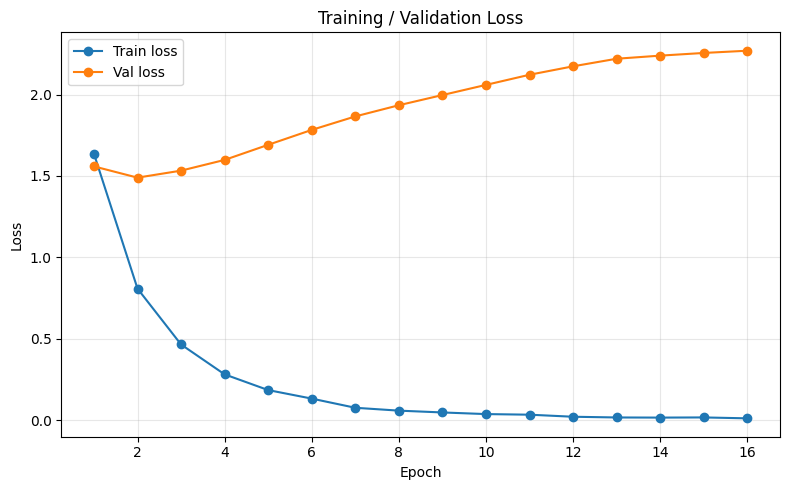

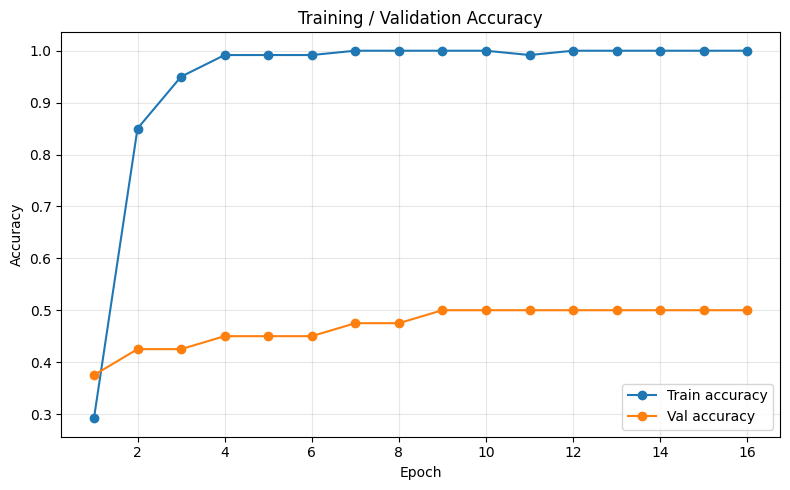

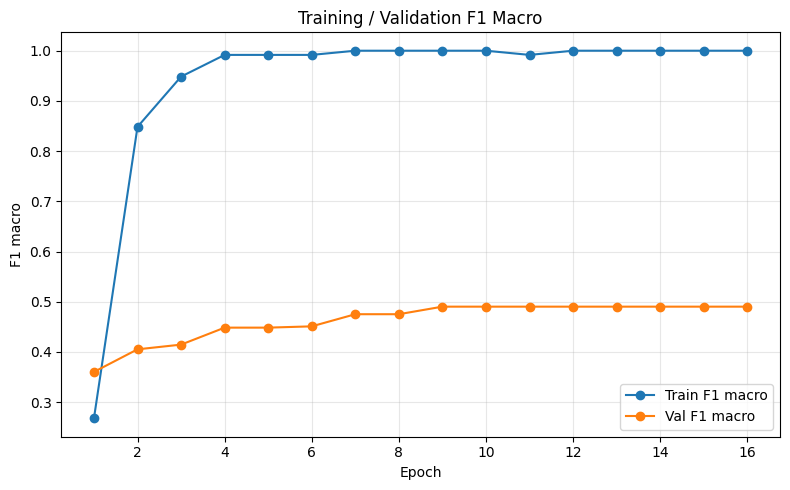

Графики сохранены в: /content/drive/MyDrive/lab2_howto100m/results


In [14]:
# ============================================================
# Графики обучения
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "loss_curve.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_curve.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1_macro"], marker="o", label="Train F1 macro")
plt.plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("Training / Validation F1 Macro")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_macro_curve.png", dpi=220)
plt.show()

print("Графики сохранены в:", RESULTS_DIR)

In [15]:
# ============================================================
# Оценка на test
# ============================================================

checkpoint = torch.load(best_model_path, map_location=DEVICE)

model = MLPVideoClassifier(
    input_dim=checkpoint["feature_dim"],
    num_classes=checkpoint["num_classes"],
    hidden_dim=checkpoint["config"]["hidden_dim"],
    dropout=checkpoint["config"]["dropout"],
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics, y_true, y_pred, y_probs = run_epoch(model, test_loader, optimizer=None)

print("TEST METRICS")
print(json.dumps(test_metrics, indent=2, ensure_ascii=False))

with open(RESULTS_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

print(report_text)

with open(RESULTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(RESULTS_DIR / "classification_report.csv", index=True)

display(report_df)

eval:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (5) will result in a perfect score and is therefore meaningless.
  warnings.warn(


TEST METRICS
{
  "loss": 1.7385711669921875,
  "accuracy": 0.55,
  "top_5_accuracy": 1.0,
  "precision_macro": 0.5583333333333333,
  "recall_macro": 0.55,
  "f1_macro": 0.5449999999999999,
  "precision_weighted": 0.5583333333333333,
  "recall_weighted": 0.55,
  "f1_weighted": 0.5449999999999999
}
                   precision    recall  f1-score   support

           Crafts       0.50      0.75      0.60         8
            Games       0.67      0.50      0.57         8
             Toys       0.62      0.62      0.62         8
Tricks and Pranks       0.50      0.38      0.43         8
      Woodworking       0.50      0.50      0.50         8

         accuracy                           0.55        40
        macro avg       0.56      0.55      0.54        40
     weighted avg       0.56      0.55      0.54        40



,precision,recall,f1-score,support
Crafts,0.500000,0.750,0.600000,8.00
Games,0.666667,0.500,0.571429,8.00
Toys,0.625000,0.625,0.625000,8.00
Tricks and Pranks,0.500000,0.375,0.428571,8.00
Woodworking,0.500000,0.500,0.500000,8.00
accuracy,0.550000,0.550,0.550000,0.55
macro avg,0.558333,0.550,0.545000,40.00
weighted avg,0.558333,0.550,0.545000,40.00


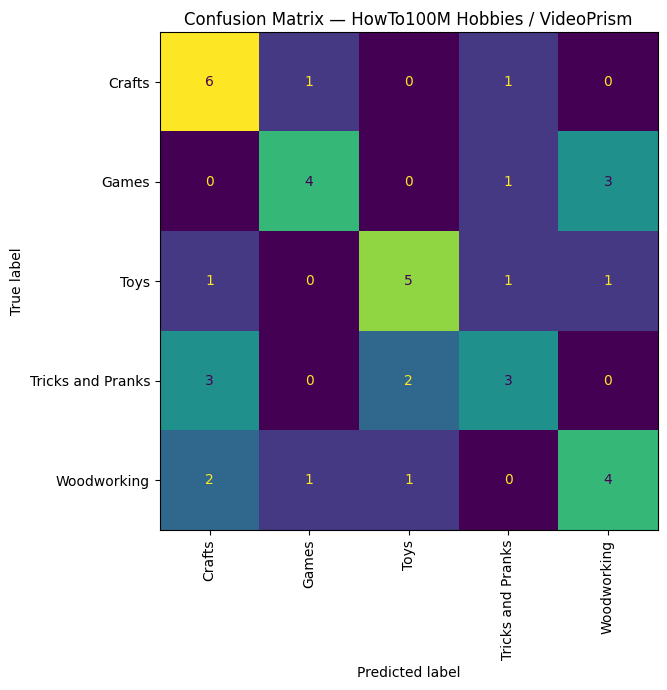

Confusion matrix сохранена: /content/drive/MyDrive/lab2_howto100m/results/confusion_matrix.png


In [16]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

fig_size = max(7, min(20, num_classes * 1.2))

plt.figure(figsize=(fig_size, fig_size))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

disp.plot(
    include_values=True,
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False,
)

plt.title("Confusion Matrix — HowTo100M Hobbies / VideoPrism")
plt.tight_layout()

cm_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=220)
plt.show()

np.save(RESULTS_DIR / "confusion_matrix.npy", cm)

print("Confusion matrix сохранена:", cm_path)

In [17]:
# ============================================================
# Анализ ошибок классификации
# ============================================================

test_out_df = test_df.reset_index(drop=True).copy()

test_out_df["true_label_id"] = y_true
test_out_df["pred_label_id"] = y_pred
test_out_df["true_label_name"] = [class_names[i] for i in y_true]
test_out_df["pred_label_name"] = [class_names[i] for i in y_pred]
test_out_df["pred_confidence"] = y_probs.max(axis=1)
test_out_df["is_correct"] = test_out_df["true_label_id"] == test_out_df["pred_label_id"]

for i, cls in enumerate(class_names):
    test_out_df[f"prob_{cls}"] = y_probs[:, i]

predictions_path = RESULTS_DIR / "test_predictions.csv"
test_out_df.to_csv(predictions_path, index=False)

errors_df = test_out_df[~test_out_df["is_correct"]].copy()
errors_df = errors_df.sort_values("pred_confidence", ascending=False)

errors_path = RESULTS_DIR / "misclassified_examples.csv"
errors_df.to_csv(errors_path, index=False)

print("Все предсказания сохранены:", predictions_path)
print("Ошибочные предсказания сохранены:", errors_path)
print("Количество ошибок:", len(errors_df))

display(errors_df[[
    "video_id",
    "category_1",
    "category_2",
    "true_label_name",
    "pred_label_name",
    "pred_confidence",
    "video_path",
    "feature_path",
]].head(20))

Все предсказания сохранены: /content/drive/MyDrive/lab2_howto100m/results/test_predictions.csv
Ошибочные предсказания сохранены: /content/drive/MyDrive/lab2_howto100m/results/misclassified_examples.csv
Количество ошибок: 18


,video_id,category_1,category_2,true_label_name,pred_label_name,pred_confidence,video_path,feature_path
27,PkYYwqyyXdQ,Hobbies and Crafts,Crafts,Crafts,Games,0.984045,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
22,JEGO2m8Rytc,Hobbies and Crafts,Games,Games,Woodworking,0.983209,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
0,BF9sm7npKPs,Hobbies and Crafts,Games,Games,Woodworking,0.979450,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
21,7BSkS1xa5AM,Hobbies and Crafts,Toys,Toys,Crafts,0.969618,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
39,ZnD_R6eOZyM,Hobbies and Crafts,Woodworking,Woodworking,Toys,0.903409,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
4,mBoZIYq6VbE,Hobbies and Crafts,Woodworking,Woodworking,Games,0.878950,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
9,PuPgxIXq_fc,Hobbies and Crafts,Tricks and Pranks,Tricks and Pranks,Crafts,0.866169,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
12,IMolvDI1awU,Hobbies and Crafts,Games,Games,Tricks and Pranks,0.839052,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
20,d_bJe4CYo-A,Hobbies and Crafts,Games,Games,Woodworking,0.777859,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...
13,Czkr8vkzE38,Hobbies and Crafts,Tricks and Pranks,Tricks and Pranks,Crafts,0.756987,/content/drive/MyDrive/lab2_howto100m/videos/v...,/content/drive/MyDrive/lab2_howto100m/videopri...


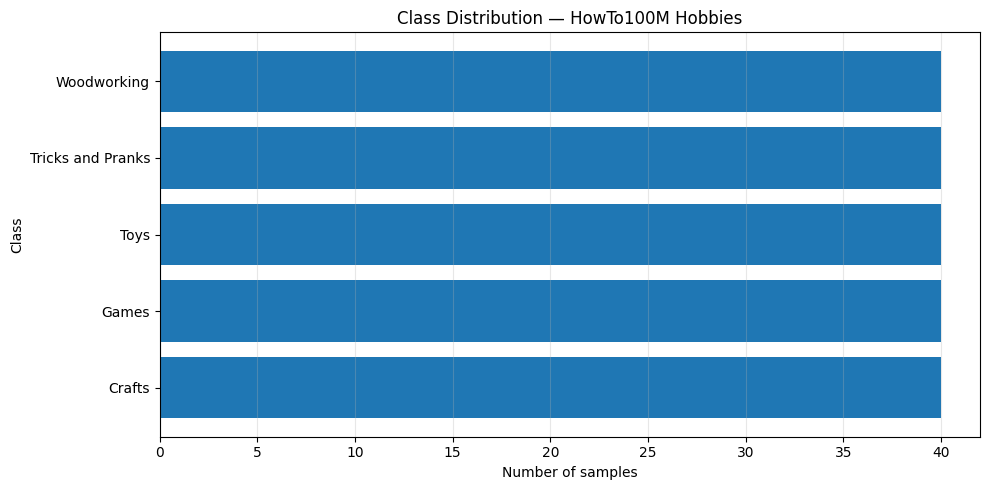

График распределения классов сохранён: /content/drive/MyDrive/lab2_howto100m/results/class_distribution.png


In [18]:
# ============================================================
# График распределения классов
# ============================================================

class_dist = data_df[LABEL_COLUMN].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, max(5, len(class_dist) * 0.5)))
plt.barh(class_dist.index, class_dist.values)
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.title("Class Distribution — HowTo100M Hobbies")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()

class_dist_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(class_dist_path, dpi=220)
plt.show()

class_dist.to_csv(RESULTS_DIR / "class_distribution.csv")

print("График распределения классов сохранён:", class_dist_path)

In [19]:


def metrics_to_markdown_table(metrics):
    rows = ["| Metric | Value |", "|---|---:|"]

    for k, v in metrics.items():
        rows.append(f"| {k} | {v:.4f} |")

    return "\n".join(rows)


def class_report_to_markdown(report_df):
    df_md = report_df.copy()

    for col in df_md.columns:
        if pd.api.types.is_numeric_dtype(df_md[col]):
            df_md[col] = df_md[col].map(lambda x: f"{x:.4f}")

    try:
        return df_md.to_markdown()
    except Exception:
        return df_md.to_string()


experiment_config = {
    "dataset": "HowTo100M",
    "subset": "Hobbies / Hobbies and Crafts",
    "label_column": LABEL_COLUMN,
    "feature_extractor": "VideoPrism",
    "videoprism_model": VIDEOPRISM_MODEL_NAME,
    "classifier": "MLP over frozen VideoPrism vectors",
    "feature_dim": int(FEATURE_DIM),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "num_samples_total": int(len(data_df)),
    "num_train": int(len(train_df)),
    "num_val": int(len(val_df)),
    "num_test": int(len(test_df)),
    "max_classes": int(MAX_CLASSES),
    "videos_per_class_target": int(VIDEOS_PER_CLASS),
    "min_samples_per_class": int(MIN_SAMPLES_PER_CLASS),
    "num_frames": int(NUM_FRAMES),
    "frame_size": int(FRAME_SIZE),
    "batch_size": int(BATCH_SIZE),
    "num_epochs_requested": int(NUM_EPOCHS),
    "best_epoch": int(best_epoch),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "hidden_dim": int(HIDDEN_DIM),
    "dropout": float(DROPOUT),
    "seed": int(SEED),
}

with open(RESULTS_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

readme_lines = []

readme_lines.append("# Лабораторная работа 2 — Классификация видео")
readme_lines.append("")
readme_lines.append("## Цель работы")
readme_lines.append("")
readme_lines.append("Получить опыт работы с видеоданными и реализовать pipeline классификации видео.")
readme_lines.append("")
readme_lines.append("## Постановка задачи")
readme_lines.append("")
readme_lines.append("В работе решается задача классификации видео из подмножества **HowTo100M | Hobbies**.")
readme_lines.append("")
readme_lines.append("- Датасет: **HowTo100M**")
readme_lines.append("- Подмножество: **Hobbies / Hobbies and Crafts**")
readme_lines.append(f"- Целевая метка: `{LABEL_COLUMN}`")
readme_lines.append("- Векторы: **VideoPrism**")
readme_lines.append("- Модель: **обучаемый MLP-классификатор поверх VideoPrism-векторов**")
readme_lines.append("")
readme_lines.append("## Данные")
readme_lines.append("")
readme_lines.append("Для эксперимента была автоматически скачана небольшая подвыборка видео из metadata HowTo100M.")
readme_lines.append("Часть исходных YouTube-видео может быть недоступна, поэтому итоговый размер выборки определяется только успешно скачанными и обработанными видео.")
readme_lines.append("")
readme_lines.append(f"- Всего объектов после фильтрации: **{len(data_df)}**")
readme_lines.append(f"- Число классов: **{num_classes}**")
readme_lines.append(f"- Train: **{len(train_df)}**")
readme_lines.append(f"- Validation: **{len(val_df)}**")
readme_lines.append(f"- Test: **{len(test_df)}**")
readme_lines.append("")
readme_lines.append("## Предобработка видео")
readme_lines.append("")
readme_lines.append("1. Загрузка короткого фрагмента видео.")
readme_lines.append(f"2. Извлечение `{NUM_FRAMES}` кадров.")
readme_lines.append(f"3. Resize кадров до `{FRAME_SIZE}x{FRAME_SIZE}`.")
readme_lines.append("4. Нормализация RGB-значений в диапазон `[0, 1]`.")
readme_lines.append("5. Передача кадров в VideoPrism.")
readme_lines.append("6. Mean pooling по токенам VideoPrism для получения одного вектора на видео.")
readme_lines.append("")
readme_lines.append("## Извлечение признаков")
readme_lines.append("")
readme_lines.append(f"Использовался VideoPrism: `{VIDEOPRISM_MODEL_NAME}`.")
readme_lines.append("")
readme_lines.append(f"Размерность итогового вектора: `D = {FEATURE_DIM}`")
readme_lines.append("")
readme_lines.append("## Архитектура модели")
readme_lines.append("")
readme_lines.append("Использовался MLP-классификатор:")
readme_lines.append("")
readme_lines.append(f"- Linear(D -> {HIDDEN_DIM})")
readme_lines.append("- LayerNorm")
readme_lines.append("- GELU")
readme_lines.append(f"- Dropout({DROPOUT})")
readme_lines.append(f"- Linear({HIDDEN_DIM} -> {HIDDEN_DIM // 2})")
readme_lines.append("- LayerNorm")
readme_lines.append("- GELU")
readme_lines.append(f"- Dropout({DROPOUT})")
readme_lines.append(f"- Linear({HIDDEN_DIM // 2} -> {num_classes})")
readme_lines.append("")
readme_lines.append("Функция потерь: `CrossEntropyLoss`.")
readme_lines.append("")
readme_lines.append(f"Оптимизатор: `AdamW`, learning rate = `{LEARNING_RATE}`, weight decay = `{WEIGHT_DECAY}`.")
readme_lines.append("")
readme_lines.append("## Метрики на test")
readme_lines.append("")
readme_lines.append(metrics_to_markdown_table(test_metrics))
readme_lines.append("")
readme_lines.append("## Графики")
readme_lines.append("")
readme_lines.append("### Распределение классов")
readme_lines.append("")
readme_lines.append("![Class Distribution](class_distribution.png)")
readme_lines.append("")
readme_lines.append("### Loss")
readme_lines.append("")
readme_lines.append("![Loss Curve](loss_curve.png)")
readme_lines.append("")
readme_lines.append("### Accuracy")
readme_lines.append("")
readme_lines.append("![Accuracy Curve](accuracy_curve.png)")
readme_lines.append("")
readme_lines.append("### F1 Macro")
readme_lines.append("")
readme_lines.append("![F1 Macro Curve](f1_macro_curve.png)")
readme_lines.append("")
readme_lines.append("### Confusion Matrix")
readme_lines.append("")
readme_lines.append("![Confusion Matrix](confusion_matrix.png)")
readme_lines.append("")
readme_lines.append("## Classification Report")
readme_lines.append("")
readme_lines.append(class_report_to_markdown(report_df))
readme_lines.append("")
readme_lines.append("## Анализ ошибок")
readme_lines.append("")
readme_lines.append("Файл с ошибочными предсказаниями: `misclassified_examples.csv`.")
readme_lines.append("Файл со всеми предсказаниями: `test_predictions.csv`.")
readme_lines.append("")
readme_lines.append("## Вывод")
readme_lines.append("")
readme_lines.append("В ходе лабораторной работы был реализован полный pipeline видеоклассификации:")
readme_lines.append("")
readme_lines.append("1. Получение metadata HowTo100M.")
readme_lines.append("2. Выбор подмножества Hobbies.")
readme_lines.append("3. Автоматическая загрузка небольшой выборки видео.")
readme_lines.append("4. Извлечение кадров.")
readme_lines.append("5. Получение VideoPrism-векторов.")
readme_lines.append("6. Обучение классификатора.")
readme_lines.append("7. Оценка качества по Accuracy, Precision, Recall, F1-score и Top-K Accuracy.")
readme_lines.append("8. Построение confusion matrix.")
readme_lines.append("9. Анализ ошибок классификации.")

readme = "\n".join(readme_lines)

readme_path = RESULTS_DIR / "README_results.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme)

print("experiment_config.json сохранён")
print("README_results.md сохранён:", readme_path)

experiment_config.json сохранён
README_results.md сохранён: /content/drive/MyDrive/lab2_howto100m/results/README_results.md


In [20]:
# ============================================================
# Архивирование папки results
# ============================================================

zip_output = PROJECT_DIR / "lab2_results"

archive_path = shutil.make_archive(
    base_name=str(zip_output),
    format="zip",
    root_dir=RESULTS_DIR,
)

print("Архив создан:", archive_path)
print("Папка results:", RESULTS_DIR)

print("\nФайлы в results:")
for p in sorted(RESULTS_DIR.iterdir()):
    print("-", p.name)

Архив создан: /content/drive/MyDrive/lab2_howto100m/lab2_results.zip
Папка results: /content/drive/MyDrive/lab2_howto100m/results

Файлы в results:
- README_results.md
- accuracy_curve.png
- best_model.pt
- class_distribution.csv
- class_distribution.png
- classification_report.csv
- classification_report.txt
- confusion_matrix.npy
- confusion_matrix.png
- dataset_used.csv
- experiment_config.json
- f1_macro_curve.png
- label_mapping.json
- last_model.pt
- loss_curve.png
- misclassified_examples.csv
- standard_scaler.joblib
- test_metrics.json
- test_predictions.csv
- test_split.csv
- train_split.csv
- training_history.csv
- val_split.csv
